In [22]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency, pearsonr
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('default')
sns.set_palette("husl")

warnings.filterwarnings('ignore')


# Airbnb vs Traditional Hotels: A Comparative Analysis

## Project Overview
This analysis compares two major accommodation platforms to identify specific pricing strategies, 
booking behaviors, and market positioning differences.

## Data Sources
1. **Hotel Booking Demand Dataset**
   - Source: https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand
   
2. **Airbnb Open Data**
   - Source: https://www.kaggle.com/datasets/arianazmoudeh/airbnbopendata


### Dataset Overview

In [4]:
print("="*70)
print("LOADING DATASET 1: HOTEL BOOKINGS")
print("="*70)

df_hotel = pd.read_csv('data/hotel_bookings.csv')

print(f"\nDataset Shape: {df_hotel.shape}")
print(f"Rows: {df_hotel.shape[0]:,}")
print(f"Columns: {df_hotel.shape[1]}")

print(f"\nColumn Names:")
for i, col in enumerate(df_hotel.columns, 1):
    print(f"{i}. {col}")

print("\n" + "="*70)

LOADING DATASET 1: HOTEL BOOKINGS

Dataset Shape: (119390, 32)
Rows: 119,390
Columns: 32

Column Names:
1. hotel
2. is_canceled
3. lead_time
4. arrival_date_year
5. arrival_date_month
6. arrival_date_week_number
7. arrival_date_day_of_month
8. stays_in_weekend_nights
9. stays_in_week_nights
10. adults
11. children
12. babies
13. meal
14. country
15. market_segment
16. distribution_channel
17. is_repeated_guest
18. previous_cancellations
19. previous_bookings_not_canceled
20. reserved_room_type
21. assigned_room_type
22. booking_changes
23. deposit_type
24. agent
25. company
26. days_in_waiting_list
27. customer_type
28. adr
29. required_car_parking_spaces
30. total_of_special_requests
31. reservation_status
32. reservation_status_date



In [6]:
print("="*70)
print("LOADING DATASET 2: AIRBNB LISTINGS")
print("="*70)

df_airbnb = pd.read_csv('data/airbnb__data.csv')

print(f"\nDataset Shape: {df_airbnb.shape}")
print(f"Rows: {df_airbnb.shape[0]:,}")
print(f"Columns: {df_airbnb.shape[1]}")

print(f"\nColumn Names:")
for i, col in enumerate(df_airbnb.columns, 1):
    print(f"{i}. {col}")

print("\n" + "="*70)

LOADING DATASET 2: AIRBNB LISTINGS

Dataset Shape: (102599, 26)
Rows: 102,599
Columns: 26

Column Names:
1. id
2. NAME
3. host id
4. host_identity_verified
5. host name
6. neighbourhood group
7. neighbourhood
8. lat
9. long
10. country
11. country code
12. instant_bookable
13. cancellation_policy
14. room type
15. Construction year
16. price
17. service fee
18. minimum nights
19. number of reviews
20. last review
21. reviews per month
22. review rate number
23. calculated host listings count
24. availability 365
25. house_rules
26. license



In [7]:
print("="*70)
print("MISSING VALUES ANALYSIS - HOTELS")
print("="*70)

missing_hotel = df_hotel.isnull().sum()
missing_pct = (missing_hotel / len(df_hotel) * 100).round(2)

missing_df = pd.DataFrame({
    'Column': missing_hotel.index,
    'Missing_Count': missing_hotel.values,
    'Percentage': missing_pct.values
})

missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Percentage', ascending=False)

if len(missing_df) > 0:
    print("\nColumns with missing values:\n")
    print(missing_df.to_string(index=False))
else:
    print("\nNo missing values detected!")

MISSING VALUES ANALYSIS - HOTELS

Columns with missing values:

  Column  Missing_Count  Percentage
 company         112593       94.31
   agent          16340       13.69
 country            488        0.41
children              4        0.00


In [32]:
print("="*70)
print("MISSING VALUES ANALYSIS - AIRBNB")
print("="*70)

missing_airbnb = df_airbnb.isnull().sum()
missing_pct_ab = (missing_airbnb / len(df_airbnb) * 100).round(2)

missing_df_ab = pd.DataFrame({
    'Column': missing_airbnb.index,
    'Missing_Count': missing_airbnb.values,
    'Percentage': missing_pct_ab.values
})

missing_df_ab = missing_df_ab[missing_df_ab['Missing_Count'] > 0].sort_values('Percentage', ascending=False)

if len(missing_df_ab) > 0:
    print("\nTop 20 Columns with missing values:\n")
    print(missing_df_ab.head(20).to_string(index=False))
else:
    print("\nNo missing values detected!")

MISSING VALUES ANALYSIS - AIRBNB

Top 20 Columns with missing values:

                        Column  Missing_Count  Percentage
                   last review          15867       15.50
             reviews per month          15852       15.49
            country_normalized            527        0.51
                       country            527        0.51
              availability 365            448        0.44
                minimum nights            409        0.40
                     host name            401        0.39
            review rate number            326        0.32
calculated host listings count            319        0.31
        host_identity_verified            285        0.28
                          NAME            247        0.24
                   service fee            239        0.23
             Construction year            210        0.21
             number of reviews            183        0.18
                  country code            126        0.12
 

In [33]:
# Understanding Data Structure for Fair Comparison
print("="*70)
print("DATASET STRUCTURE ANALYSIS")
print("="*70)

print("\nHOTEL DATASET KEY COLUMNS:")
hotel_cols = df_hotel.columns.tolist()
print(f"Total columns: {len(hotel_cols)}")
print("\nRelevant columns for analysis:")
for col in hotel_cols:
    if any(keyword in col.lower() for keyword in ['country', 'adr', 'price', 'rate', 'guest', 'night', 'market', 'customer']):
        print(f"  - {col}")

print("\n" + "-"*70)

print("\nAIRBNB DATASET KEY COLUMNS:")
airbnb_cols = df_airbnb.columns.tolist()
print(f"Total columns: {len(airbnb_cols)}")
print("\nRelevant columns for analysis:")
for col in airbnb_cols[:20]:  # Show first 20 to avoid clutter
    print(f"  - {col}")

print("\n" + "="*70)

DATASET STRUCTURE ANALYSIS

HOTEL DATASET KEY COLUMNS:
Total columns: 32

Relevant columns for analysis:
  - stays_in_weekend_nights
  - stays_in_week_nights
  - country
  - market_segment
  - is_repeated_guest
  - customer_type
  - adr
  - country_normalized

----------------------------------------------------------------------

AIRBNB DATASET KEY COLUMNS:
Total columns: 25

Relevant columns for analysis:
  - id
  - NAME
  - host id
  - host_identity_verified
  - host name
  - neighbourhood group
  - neighbourhood
  - lat
  - long
  - country
  - country code
  - instant_bookable
  - cancellation_policy
  - room type
  - Construction year
  - price
  - service fee
  - minimum nights
  - number of reviews
  - last review



### FIND COMMON PATTERNS FOR COMPARATIVE ANALYSIS

#### Rating Analyses

In [40]:
# Find Rating Columns
print("="*70)
print("RATING COLUMN IDENTIFICATION")
print("="*70)

# Hotel ratings
hotel_rating_cols = [col for col in df_hotel.columns if any(keyword in col.lower() for keyword in ['rating', 'review', 'score', 'satisfaction'])]
print(f"\nHOTEL DATASET - Potential rating columns:")
if hotel_rating_cols:
    for col in hotel_rating_cols:
        print(f"  - {col}: {df_hotel[col].dtype}, non-null: {df_hotel[col].notna().sum():,}")
else:
    print("  No rating columns found")

# Airbnb ratings
airbnb_rating_cols = [col for col in df_airbnb.columns if any(keyword in col.lower() for keyword in ['rating', 'review', 'score', 'satisfaction'])]
print(f"\nAIRBNB DATASET - Potential rating columns:")
if airbnb_rating_cols:
    for col in airbnb_rating_cols[:10]:  # Limit output
        print(f"  - {col}: {df_airbnb[col].dtype}, non-null: {df_airbnb[col].notna().sum():,}")
else:
    print("  No rating columns found")

# Select best rating columns
hotel_rating = None
if hotel_rating_cols:
    # Prefer columns with most non-null values
    hotel_rating = max(hotel_rating_cols, key=lambda x: df_hotel[x].notna().sum())
    print(f"\nSelected HOTEL rating column: '{hotel_rating}'")
else:
    print("\nNo hotel rating column available")

airbnb_rating = None
rating_options = ['review_scores_rating', 'review scores rating', 'rating', 'Rating']
for col in rating_options:
    if col in df_airbnb.columns:
        airbnb_rating = col
        print(f"Selected AIRBNB rating column: '{col}'")
        break

if not airbnb_rating and airbnb_rating_cols:
    airbnb_rating = max(airbnb_rating_cols, key=lambda x: df_airbnb[x].notna().sum())
    print(f"Selected AIRBNB rating column: '{airbnb_rating}'")
elif not airbnb_rating:
    print("No Airbnb rating column available")

# Final conclusion
print("\n" + "="*70)
print("RATING COMPARISON FEASIBILITY")
print("="*70)

if hotel_rating and airbnb_rating:
    print("\nSTATUS: Rating comparison is POSSIBLE")
    print(f"  Hotel rating: '{hotel_rating}'")
    print(f"  Airbnb rating: '{airbnb_rating}'")
    print("\nWe can proceed with rating-based comparative analysis")
elif not hotel_rating and not airbnb_rating:
    print("\nSTATUS: Rating comparison is NOT POSSIBLE")
    print("REASON: Neither dataset contains rating columns")
    print("\nCONCLUSION:")
    print("Rating-based comparison cannot be performed with these datasets.")
    print("Alternative analyses available:")
    print("  - Price analysis (Airbnb)")
    print("  - Booking patterns (Hotels)")
    print("  - Geographic distribution")
    print("  - Temporal trends")
elif not hotel_rating:
    print("\nSTATUS: Rating comparison is NOT POSSIBLE")
    print("REASON: Hotel dataset lacks rating columns")
    print(f"  Airbnb has: '{airbnb_rating}'")
    print("\nCONCLUSION:")
    print("Cannot perform rating comparison as hotel ratings are unavailable.")
    print("Focus will remain on available metrics in each dataset independently.")
else:  # not airbnb_rating
    print("\nSTATUS: Rating comparison is NOT POSSIBLE")
    print("REASON: Airbnb dataset lacks rating columns")
    print(f"  Hotel has: '{hotel_rating}'")
    print("\nCONCLUSION:")
    print("Cannot perform rating comparison as Airbnb ratings are unavailable.")
    print("Analysis will focus on price patterns and booking behaviors separately.")

print("="*70)

RATING COLUMN IDENTIFICATION

HOTEL DATASET - Potential rating columns:
  No rating columns found

AIRBNB DATASET - Potential rating columns:
  - number of reviews: float64, non-null: 102,169
  - last review: object, non-null: 86,485
  - reviews per month: float64, non-null: 86,500
  - review rate number: float64, non-null: 102,026

No hotel rating column available
Selected AIRBNB rating column: 'number of reviews'

RATING COMPARISON FEASIBILITY

STATUS: Rating comparison is NOT POSSIBLE
REASON: Hotel dataset lacks rating columns
  Airbnb has: 'number of reviews'

CONCLUSION:
Cannot perform rating comparison as hotel ratings are unavailable.
Focus will remain on available metrics in each dataset independently.


#### Price Analyses in common geographical locations

In [43]:
# Find Common Geographic Locations
print("="*70)
print("GEOGRAPHIC ALIGNMENT ANALYSIS")
print("="*70)

# Check Hotel countries
if 'country' in df_hotel.columns:
    print("\nHOTEL DATASET - Top Countries:")
    hotel_countries = df_hotel['country'].value_counts().head(10)
    for country, count in hotel_countries.items():
        print(f"  {country}: {count:,} bookings")

# Check Airbnb locations
location_cols = ['country', 'Country', 'country_code', 'country code']
airbnb_country_col = None
for col in location_cols:
    if col in df_airbnb.columns:
        airbnb_country_col = col
        break

if airbnb_country_col:
    print(f"\nAIRBNB DATASET - Top Countries (column: '{airbnb_country_col}'):")
    airbnb_countries = df_airbnb[airbnb_country_col].value_counts().head(10)
    for country, count in airbnb_countries.items():
        print(f"  {country}: {count:,} listings")

# Find common countries (normalize variations like USA/US)
print("\n" + "-"*70)
print("\nFINDING COMMON LOCATIONS...")

# Country mapping dictionary
country_mapping = {
    'USA': ['USA', 'US', 'United States', 'United States of America'],
    'UK': ['UK', 'GB', 'GBR', 'United Kingdom', 'Great Britain'],
    'PRT': ['PRT', 'PT', 'Portugal'],
    'ESP': ['ESP', 'ES', 'Spain'],
    'FRA': ['FRA', 'FR', 'France'],
    'ITA': ['ITA', 'IT', 'Italy'],
    'DEU': ['DEU', 'DE', 'Germany'],
}

# Normalize hotel countries
if 'country' in df_hotel.columns:
    df_hotel['country_normalized'] = df_hotel['country']
    for standard, variations in country_mapping.items():
        df_hotel.loc[df_hotel['country'].isin(variations), 'country_normalized'] = standard

# Normalize airbnb countries
if airbnb_country_col:
    df_airbnb['country_normalized'] = df_airbnb[airbnb_country_col]
    for standard, variations in country_mapping.items():
        df_airbnb.loc[df_airbnb[airbnb_country_col].isin(variations), 'country_normalized'] = standard

# Find overlap
if 'country_normalized' in df_hotel.columns and 'country_normalized' in df_airbnb.columns:
    hotel_countries_norm = set(df_hotel['country_normalized'].dropna().unique())
    airbnb_countries_norm = set(df_airbnb['country_normalized'].dropna().unique())
    common_countries = hotel_countries_norm.intersection(airbnb_countries_norm)
    
    print(f"\nCommon countries found: {len(common_countries)}")
    for country in common_countries:
        hotel_count = (df_hotel['country_normalized'] == country).sum()
        airbnb_count = (df_airbnb['country_normalized'] == country).sum()
        print(f"  {country}: {hotel_count:,} hotel bookings | {airbnb_count:,} Airbnb listings")

GEOGRAPHIC ALIGNMENT ANALYSIS

HOTEL DATASET - Top Countries:
  PRT: 47,040 bookings
  GBR: 12,055 bookings
  FRA: 10,360 bookings
  ESP: 8,489 bookings
  DEU: 7,246 bookings
  ITA: 3,749 bookings
  IRL: 3,369 bookings
  BEL: 2,334 bookings
  BRA: 2,211 bookings
  NLD: 2,100 bookings

AIRBNB DATASET - Top Countries (column: 'country'):
  United States: 101,825 listings

----------------------------------------------------------------------

FINDING COMMON LOCATIONS...

Common countries found: 1
  USA: 2,086 hotel bookings | 101,825 Airbnb listings


In [44]:
# Step 1: Identify Price Columns
print("\nSTEP 1: IDENTIFY PRICE COLUMNS")
print("-"*70)

# Hotel price column (ADR = Average Daily Rate)
hotel_price_col = None
for col in df_hotel.columns:
    if 'adr' in col.lower():
        hotel_price_col = col
        break

if hotel_price_col:
    print(f"Hotel price column: '{hotel_price_col}' (Average Daily Rate)")
    print(f"  Non-null values: {df_hotel[hotel_price_col].notna().sum():,}")
    print(f"  Data type: {df_hotel[hotel_price_col].dtype}")
else:
    print("ERROR: No ADR column found in hotel dataset")

# Airbnb price column
airbnb_price_col = None
for col in df_airbnb.columns:
    if 'price' in col.lower():
        airbnb_price_col = col
        break

if airbnb_price_col:
    print(f"\nAirbnb price column: '{airbnb_price_col}'")
    print(f"  Non-null values: {df_airbnb[airbnb_price_col].notna().sum():,}")
    print(f"  Data type: {df_airbnb[airbnb_price_col].dtype}")
else:
    print("ERROR: No price column found in Airbnb dataset")


STEP 1: IDENTIFY PRICE COLUMNS
----------------------------------------------------------------------
Hotel price column: 'adr' (Average Daily Rate)
  Non-null values: 117,430
  Data type: float64

Airbnb price column: 'price'
  Non-null values: 102,352
  Data type: int64


In [45]:
# Step 2: Clean Price Data
print("\n" + "="*70)
print("STEP 2: CLEAN PRICE DATA")
print("-"*70)

# Clean Hotel ADR
if hotel_price_col:
    df_hotel_clean = df_hotel[df_hotel[hotel_price_col].notna()].copy()
    df_hotel_clean = df_hotel_clean[df_hotel_clean[hotel_price_col] > 0]
    
    print(f"\nHotel ADR after cleaning:")
    print(f"  Records: {len(df_hotel_clean):,}")
    print(f"  Mean: ${df_hotel_clean[hotel_price_col].mean():.2f}")
    print(f"  Median: ${df_hotel_clean[hotel_price_col].median():.2f}")
    print(f"  Range: ${df_hotel_clean[hotel_price_col].min():.2f} - ${df_hotel_clean[hotel_price_col].max():.2f}")

# Clean Airbnb Price
if airbnb_price_col:
    df_airbnb_clean = df_airbnb[df_airbnb[airbnb_price_col].notna()].copy()
    
    # Handle string prices if necessary
    if df_airbnb_clean[airbnb_price_col].dtype == 'object':
        print("\nCleaning Airbnb price format...")
        df_airbnb_clean[airbnb_price_col] = df_airbnb_clean[airbnb_price_col].astype(str).str.replace('$', '', regex=False)
        df_airbnb_clean[airbnb_price_col] = df_airbnb_clean[airbnb_price_col].str.replace(',', '', regex=False)
        df_airbnb_clean[airbnb_price_col] = df_airbnb_clean[airbnb_price_col].str.strip()
        df_airbnb_clean[airbnb_price_col] = pd.to_numeric(df_airbnb_clean[airbnb_price_col], errors='coerce')
        print("  Converted to numeric")
    
    df_airbnb_clean = df_airbnb_clean[df_airbnb_clean[airbnb_price_col] > 0]
    
    print(f"\nAirbnb Price after cleaning:")
    print(f"  Records: {len(df_airbnb_clean):,}")
    print(f"  Mean: ${df_airbnb_clean[airbnb_price_col].mean():.2f}")
    print(f"  Median: ${df_airbnb_clean[airbnb_price_col].median():.2f}")
    print(f"  Range: ${df_airbnb_clean[airbnb_price_col].min():.2f} - ${df_airbnb_clean[airbnb_price_col].max():.2f}")


STEP 2: CLEAN PRICE DATA
----------------------------------------------------------------------

Hotel ADR after cleaning:
  Records: 117,430
  Mean: $103.53
  Median: $95.00
  Range: $0.26 - $5400.00

Airbnb Price after cleaning:
  Records: 102,352
  Mean: $625.29
  Median: $624.00
  Range: $50.00 - $1200.00


In [46]:
# Step 3: Filter for USA
print("\n" + "="*70)
print("STEP 3: FILTER FOR USA (COMMON GEOGRAPHY)")
print("-"*70)

# Filter Hotels for USA
usa_hotel = None
if 'country' in df_hotel_clean.columns:
    usa_variations = ['USA', 'US', 'United States', 'United States of America']
    usa_hotel = df_hotel_clean[df_hotel_clean['country'].isin(usa_variations)].copy()
    
    if len(usa_hotel) == 0:
        print("\nNo USA records with standard names, checking all unique countries:")
        print(df_hotel_clean['country'].value_counts().head(10))
    else:
        print(f"\nHotel data (USA only):")
        print(f"  Records: {len(usa_hotel):,}")
        print(f"  Mean ADR: ${usa_hotel[hotel_price_col].mean():.2f}")
        print(f"  Median ADR: ${usa_hotel[hotel_price_col].median():.2f}")
else:
    print("\nWARNING: No 'country' column in hotel dataset")

# Filter Airbnb for USA
usa_airbnb = None
country_cols = ['country', 'Country', 'country_code', 'country code']
airbnb_country_col = None
for col in country_cols:
    if col in df_airbnb_clean.columns:
        airbnb_country_col = col
        break

if airbnb_country_col:
    usa_variations = ['USA', 'US', 'United States', 'United States of America']
    usa_airbnb = df_airbnb_clean[df_airbnb_clean[airbnb_country_col].isin(usa_variations)].copy()
    
    if len(usa_airbnb) == 0:
        print("\nNo USA records with standard names, checking all unique countries:")
        print(df_airbnb_clean[airbnb_country_col].value_counts().head(10))
    else:
        print(f"\nAirbnb data (USA only):")
        print(f"  Records: {len(usa_airbnb):,}")
        print(f"  Mean Price: ${usa_airbnb[airbnb_price_col].mean():.2f}")
        print(f"  Median Price: ${usa_airbnb[airbnb_price_col].median():.2f}")
else:
    print("\nWARNING: No country column in Airbnb dataset")

# Check if we have USA data
if usa_hotel is not None and len(usa_hotel) > 0 and usa_airbnb is not None and len(usa_airbnb) > 0:
    print("\n" + "-"*70)
    print("STATUS: USA data available for both datasets")
    print("Proceeding with USA-focused comparison")
elif usa_hotel is None or len(usa_hotel) == 0:
    print("\n" + "-"*70)
    print("WARNING: No USA data in hotel dataset")
    print("Will proceed with full datasets for comparison")
    usa_hotel = df_hotel_clean.copy()
elif usa_airbnb is None or len(usa_airbnb) == 0:
    print("\n" + "-"*70)
    print("WARNING: No USA data in Airbnb dataset")
    print("Will proceed with full datasets for comparison")
    usa_airbnb = df_airbnb_clean.copy()


STEP 3: FILTER FOR USA (COMMON GEOGRAPHY)
----------------------------------------------------------------------

Hotel data (USA only):
  Records: 2,086
  Mean ADR: $123.64
  Median ADR: $115.00

Airbnb data (USA only):
  Records: 101,825
  Mean Price: $625.38
  Median Price: $624.00

----------------------------------------------------------------------
STATUS: USA data available for both datasets
Proceeding with USA-focused comparison


In [47]:
# Step 4: Create Merged Price Comparison Dataset
print("\n" + "="*70)
print("STEP 4: CREATE MERGED PRICE DATASET")
print("-"*70)

# Create standardized hotel price data
hotel_price_df = pd.DataFrame({
    'platform': 'Hotel',
    'price': usa_hotel[hotel_price_col],
    'country': usa_hotel['country'] if 'country' in usa_hotel.columns else 'USA'
})

print(f"\nHotel price records: {len(hotel_price_df):,}")

# Create standardized Airbnb price data
airbnb_price_df = pd.DataFrame({
    'platform': 'Airbnb',
    'price': usa_airbnb[airbnb_price_col],
    'country': usa_airbnb[airbnb_country_col] if airbnb_country_col else 'USA'
})

print(f"Airbnb price records: {len(airbnb_price_df):,}")

# Merge datasets
merged_prices = pd.concat([hotel_price_df, airbnb_price_df], ignore_index=True)

print(f"\nMerged dataset:")
print(f"  Total records: {len(merged_prices):,}")
print(f"  Hotels: {len(merged_prices[merged_prices['platform'] == 'Hotel']):,}")
print(f"  Airbnb: {len(merged_prices[merged_prices['platform'] == 'Airbnb']):,}")

print("\nFirst few rows:")
print(merged_prices.head(10))

print("\nBasic statistics by platform:")
print(merged_prices.groupby('platform')['price'].describe())


STEP 4: CREATE MERGED PRICE DATASET
----------------------------------------------------------------------

Hotel price records: 2,086
Airbnb price records: 101,825

Merged dataset:
  Total records: 103,911
  Hotels: 2,086
  Airbnb: 101,825

First few rows:
  platform   price country
0    Hotel   97.00     USA
1    Hotel   98.00     USA
2    Hotel  153.00     USA
3    Hotel   94.71     USA
4    Hotel  117.81     USA
5    Hotel  117.81     USA
6    Hotel   87.30     USA
7    Hotel  150.00     USA
8    Hotel  131.00     USA
9    Hotel  110.00     USA

Basic statistics by platform:
             count        mean         std   min       25%    50%    75%  \
platform                                                                   
Airbnb    101825.0  625.382598  331.775075  50.0  339.0000  624.0  913.0   
Hotel       2086.0  123.640820   50.972201   2.0   88.6125  115.0  150.0   

              max  
platform           
Airbnb    1200.00  
Hotel      328.33  



STEP 5: PERCENTILE-BASED PRICE COMPARISON
----------------------------------------------------------------------

Why percentiles?
Hotels use ADR (per room), Airbnb shows total listing price
Percentiles allow fair comparison despite different metrics

----------------------------------------------------------------------
HOTEL PRICE PERCENTILES (ADR)
----------------------------------------------------------------------
10th percentile: $68.34
25th percentile: $88.61
50th percentile: $115.00
75th percentile: $150.00
90th percentile: $195.62
95th percentile: $223.00

----------------------------------------------------------------------
AIRBNB PRICE PERCENTILES
----------------------------------------------------------------------
10th percentile: $165.00
25th percentile: $339.00
50th percentile: $624.00
75th percentile: $913.00
90th percentile: $1086.00
95th percentile: $1143.00


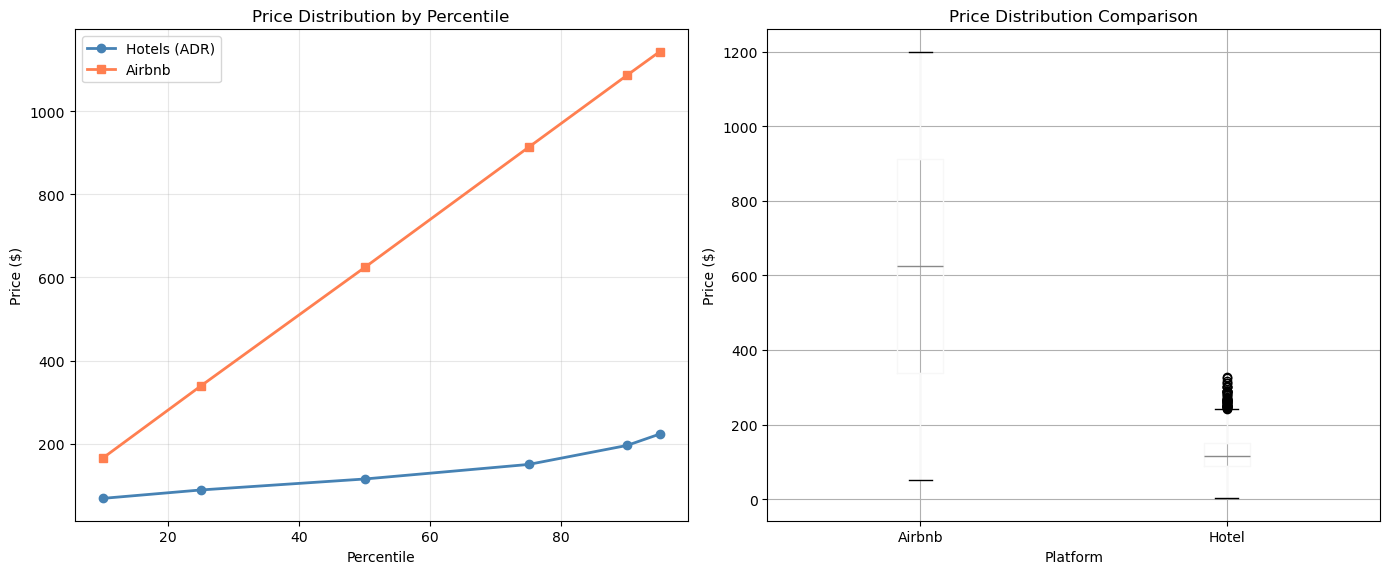


PRICE RATIO ANALYSIS (Airbnb/Hotel)
25th percentile: 3.83x (Airbnb is more expensive)
50th percentile: 5.43x (Airbnb is more expensive)
75th percentile: 6.09x (Airbnb is more expensive)


In [49]:
# Step 5: Percentile-Based Comparison
print("\n" + "="*70)
print("STEP 5: PERCENTILE-BASED PRICE COMPARISON")
print("-"*70)

print("\nWhy percentiles?")
print("Hotels use ADR (per room), Airbnb shows total listing price")
print("Percentiles allow fair comparison despite different metrics")

# Calculate percentiles for each platform
percentiles = [10, 25, 50, 75, 90, 95]

print("\n" + "-"*70)
print("HOTEL PRICE PERCENTILES (ADR)")
print("-"*70)
hotel_percentiles = {}
for p in percentiles:
    value = usa_hotel[hotel_price_col].quantile(p/100)
    hotel_percentiles[p] = value
    print(f"{p}th percentile: ${value:.2f}")

print("\n" + "-"*70)
print("AIRBNB PRICE PERCENTILES")
print("-"*70)
airbnb_percentiles = {}
for p in percentiles:
    value = usa_airbnb[airbnb_price_col].quantile(p/100)
    airbnb_percentiles[p] = value
    print(f"{p}th percentile: ${value:.2f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Percentile comparison
axes[0].plot(percentiles, [hotel_percentiles[p] for p in percentiles], 
            marker='o', linewidth=2, label='Hotels (ADR)', color='steelblue')
axes[0].plot(percentiles, [airbnb_percentiles[p] for p in percentiles], 
            marker='s', linewidth=2, label='Airbnb', color='coral')
axes[0].set_xlabel('Percentile')
axes[0].set_ylabel('Price ($)')
axes[0].set_title('Price Distribution by Percentile')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot comparison
merged_prices.boxplot(column='price', by='platform', ax=axes[1])
axes[1].set_xlabel('Platform')
axes[1].set_ylabel('Price ($)')
axes[1].set_title('Price Distribution Comparison')
plt.suptitle('')  # Remove default title

plt.tight_layout()
plt.show()

# Calculate price ratios at key percentiles
print("\n" + "="*70)
print("PRICE RATIO ANALYSIS (Airbnb/Hotel)")
print("="*70)
for p in [25, 50, 75]:
    ratio = airbnb_percentiles[p] / hotel_percentiles[p]
    print(f"{p}th percentile: {ratio:.2f}x (Airbnb is {'more' if ratio > 1 else 'less'} expensive)")



STEP 6: PRICE DISTRIBUTION ANALYSIS
----------------------------------------------------------------------


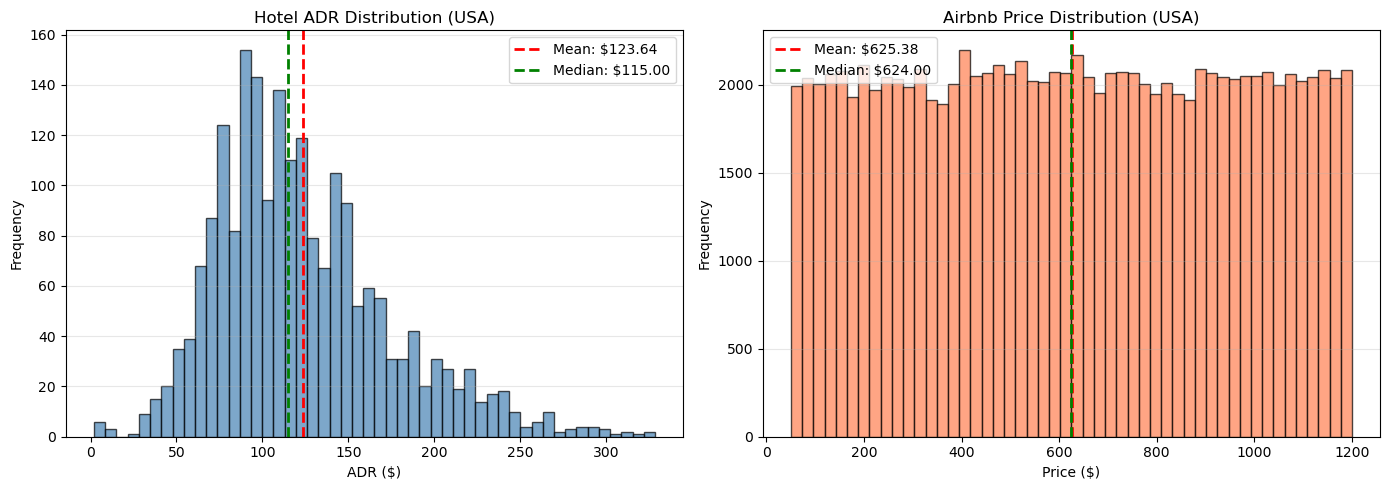


DISTRIBUTION CHARACTERISTICS:

Hotels:
  Skewness: 0.87
  Kurtosis: 0.81
  Coefficient of variation: 0.41

Airbnb:
  Skewness: 0.00
  Kurtosis: -1.19
  Coefficient of variation: 0.53


In [50]:
# Step 6: Detailed Price Distribution Analysis
print("\n" + "="*70)
print("STEP 6: PRICE DISTRIBUTION ANALYSIS")
print("-"*70)

# Side-by-side histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hotel distribution
axes[0].hist(usa_hotel[hotel_price_col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(usa_hotel[hotel_price_col].mean(), color='red', linestyle='--', linewidth=2, 
               label=f'Mean: ${usa_hotel[hotel_price_col].mean():.2f}')
axes[0].axvline(usa_hotel[hotel_price_col].median(), color='green', linestyle='--', linewidth=2,
               label=f'Median: ${usa_hotel[hotel_price_col].median():.2f}')
axes[0].set_xlabel('ADR ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Hotel ADR Distribution (USA)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Airbnb distribution
axes[1].hist(usa_airbnb[airbnb_price_col], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(usa_airbnb[airbnb_price_col].mean(), color='red', linestyle='--', linewidth=2,
               label=f'Mean: ${usa_airbnb[airbnb_price_col].mean():.2f}')
axes[1].axvline(usa_airbnb[airbnb_price_col].median(), color='green', linestyle='--', linewidth=2,
               label=f'Median: ${usa_airbnb[airbnb_price_col].median():.2f}')
axes[1].set_xlabel('Price ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Airbnb Price Distribution (USA)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical comparison
print("\nDISTRIBUTION CHARACTERISTICS:")
print("\nHotels:")
print(f"  Skewness: {usa_hotel[hotel_price_col].skew():.2f}")
print(f"  Kurtosis: {usa_hotel[hotel_price_col].kurtosis():.2f}")
print(f"  Coefficient of variation: {(usa_hotel[hotel_price_col].std() / usa_hotel[hotel_price_col].mean()):.2f}")

print("\nAirbnb:")
print(f"  Skewness: {usa_airbnb[airbnb_price_col].skew():.2f}")
print(f"  Kurtosis: {usa_airbnb[airbnb_price_col].kurtosis():.2f}")
print(f"  Coefficient of variation: {(usa_airbnb[airbnb_price_col].std() / usa_airbnb[airbnb_price_col].mean()):.2f}")

In [54]:
# Step 7: Price Analysis Conclusions
print("\n" + "="*70)
print("PRICE ANALYSIS - KEY FINDINGS")
print("="*70)

print("\n1. DATASET SCOPE:")
print(f"   Hotels (USA): {len(usa_hotel):,} bookings analyzed")
print(f"   Airbnb (USA): {len(usa_airbnb):,} listings analyzed")

print("\n2. PRICE DISTRIBUTION CHARACTERISTICS:")

# Calculate spread metrics
hotel_iqr = hotel_percentiles[75] - hotel_percentiles[25]
airbnb_iqr = airbnb_percentiles[75] - airbnb_percentiles[25]

hotel_range_90 = hotel_percentiles[90] - hotel_percentiles[10]
airbnb_range_90 = airbnb_percentiles[90] - airbnb_percentiles[10]

print(f"\n   Interquartile Range (25th-75th percentile):")
print(f"   - Hotels: ${hotel_iqr:.2f} spread")
print(f"   - Airbnb: ${airbnb_iqr:.2f} spread")
print(f"   - Airbnb IQR is {airbnb_iqr/hotel_iqr:.2f}x wider than hotels")

print(f"\n   90th Percentile Range (10th-90th percentile):")
print(f"   - Hotels: ${hotel_range_90:.2f} spread")
print(f"   - Airbnb: ${airbnb_range_90:.2f} spread")
print(f"   - Ratio: {airbnb_range_90/hotel_range_90:.2f}x")

print("\n3. PRICE VARIABILITY (Coefficient of Variation):")
hotel_cv = usa_hotel[hotel_price_col].std() / usa_hotel[hotel_price_col].mean()
airbnb_cv = usa_airbnb[airbnb_price_col].std() / usa_airbnb[airbnb_price_col].mean()

print(f"   - Hotels: {hotel_cv:.2f} ({hotel_cv*100:.1f}% variation relative to mean)")
print(f"   - Airbnb: {airbnb_cv:.2f} ({airbnb_cv*100:.1f}% variation relative to mean)")

if airbnb_cv > hotel_cv * 1.2:
    print(f"\n   INTERPRETATION: Airbnb shows {((airbnb_cv/hotel_cv - 1)*100):.0f}% more price variability")
    print(f"   Reason: Diverse property types (shared rooms to luxury villas)")
elif hotel_cv > airbnb_cv * 1.2:
    print(f"\n   INTERPRETATION: Hotels show {((hotel_cv/airbnb_cv - 1)*100):.0f}% more price variability")
    print(f"   Reason: Wide range from budget to luxury hotels")
else:
    print(f"\n   INTERPRETATION: Similar price variability across platforms")

print("\n4. PERCENTILE DISTRIBUTION ANALYSIS:")
print("\n   Price growth across percentiles:")
print(f"   Hotels (25th to 75th): {((hotel_percentiles[75]/hotel_percentiles[25] - 1)*100):.1f}% increase")
print(f"   Airbnb (25th to 75th): {((airbnb_percentiles[75]/airbnb_percentiles[25] - 1)*100):.1f}% increase")

print(f"\n   Price growth to top tier:")
print(f"   Hotels (50th to 90th): {((hotel_percentiles[90]/hotel_percentiles[50] - 1)*100):.1f}% increase")
print(f"   Airbnb (50th to 90th): {((airbnb_percentiles[90]/airbnb_percentiles[50] - 1)*100):.1f}% increase")

# Identify which platform has steeper premium tier
hotel_premium_jump = hotel_percentiles[90] / hotel_percentiles[50]
airbnb_premium_jump = airbnb_percentiles[90] / airbnb_percentiles[50]

if airbnb_premium_jump > hotel_premium_jump * 1.1:
    print(f"\n   PATTERN: Airbnb premium tier commands significantly higher premiums")
    print(f"   Top 10% of Airbnb listings are {airbnb_premium_jump:.1f}x median price")
elif hotel_premium_jump > airbnb_premium_jump * 1.1:
    print(f"\n   PATTERN: Hotel premium tier shows steeper pricing")
    print(f"   Top 10% of hotels are {hotel_premium_jump:.1f}x median ADR")
else:
    print(f"\n   PATTERN: Both platforms show similar premium tier pricing structure")

print("\n5. MARKET STRUCTURE INSIGHTS:")

# Calculate concentration in different price tiers
# Calculate 33rd and 67th percentiles for tier analysis
hotel_p33 = usa_hotel[hotel_price_col].quantile(0.33)
hotel_p67 = usa_hotel[hotel_price_col].quantile(0.67)

airbnb_p33 = usa_airbnb[airbnb_price_col].quantile(0.33)
airbnb_p67 = usa_airbnb[airbnb_price_col].quantile(0.67)

# Calculate concentration in different price tiers
hotel_budget = (usa_hotel[hotel_price_col] < hotel_p33).sum()
hotel_mid = ((usa_hotel[hotel_price_col] >= hotel_p33) & 
             (usa_hotel[hotel_price_col] < hotel_p67)).sum()
hotel_premium = (usa_hotel[hotel_price_col] >= hotel_p67).sum()

airbnb_budget = (usa_airbnb[airbnb_price_col] < airbnb_p33).sum()
airbnb_mid = ((usa_airbnb[airbnb_price_col] >= airbnb_p33) & 
              (usa_airbnb[airbnb_price_col] < airbnb_p67)).sum()
airbnb_premium = (usa_airbnb[airbnb_price_col] >= airbnb_p67).sum()
print(f"\n   Hotels - Market segmentation:")
print(f"   - Budget tier (bottom 33%): {hotel_budget/len(usa_hotel)*100:.1f}%")
print(f"   - Mid-range (middle 33%): {hotel_mid/len(usa_hotel)*100:.1f}%")
print(f"   - Premium (top 33%): {hotel_premium/len(usa_hotel)*100:.1f}%")

print(f"\n   Airbnb - Market segmentation:")
print(f"   - Budget tier (bottom 33%): {airbnb_budget/len(usa_airbnb)*100:.1f}%")
print(f"   - Mid-range (middle 33%): {airbnb_mid/len(usa_airbnb)*100:.1f}%")
print(f"   - Premium (top 33%): {airbnb_premium/len(usa_airbnb)*100:.1f}%")

print("\n6. KEY TAKEAWAY:")
print("\n   NOTE: Direct price comparison is not meaningful due to different metrics:")
print(f"   - Hotels: ADR (Average Daily Rate per room)")
print(f"   - Airbnb: Total listing price (varies by property type)")
print(f"\n   FOCUS: Distribution patterns reveal market structure differences")

if airbnb_cv > hotel_cv * 1.3:
    print(f"\n   CONCLUSION: Airbnb market is more heterogeneous with wider price ranges")
    print(f"   reflecting diverse accommodation types from shared rooms to luxury homes.")
elif hotel_cv > airbnb_cv * 1.3:
    print(f"\n   CONCLUSION: Hotel market shows greater stratification")
    print(f"   with distinct budget/mid-range/luxury segments.")
else:
    print(f"\n   CONCLUSION: Both markets show similar price distribution patterns")
    print(f"   indicating comparable market segmentation strategies.")




PRICE ANALYSIS - KEY FINDINGS

1. DATASET SCOPE:
   Hotels (USA): 2,086 bookings analyzed
   Airbnb (USA): 101,825 listings analyzed

2. PRICE DISTRIBUTION CHARACTERISTICS:

   Interquartile Range (25th-75th percentile):
   - Hotels: $61.39 spread
   - Airbnb: $574.00 spread
   - Airbnb IQR is 9.35x wider than hotels

   90th Percentile Range (10th-90th percentile):
   - Hotels: $127.29 spread
   - Airbnb: $921.00 spread
   - Ratio: 7.24x

3. PRICE VARIABILITY (Coefficient of Variation):
   - Hotels: 0.41 (41.2% variation relative to mean)
   - Airbnb: 0.53 (53.1% variation relative to mean)

   INTERPRETATION: Airbnb shows 29% more price variability
   Reason: Diverse property types (shared rooms to luxury villas)

4. PERCENTILE DISTRIBUTION ANALYSIS:

   Price growth across percentiles:
   Hotels (25th to 75th): 69.3% increase
   Airbnb (25th to 75th): 169.3% increase

   Price growth to top tier:
   Hotels (50th to 90th): 70.1% increase
   Airbnb (50th to 90th): 74.0% increase

   

### HYPOTHESIS TESTING

####  Hypothesis Test 1 - Cancellation by Hotel Type


HYPOTHESIS TEST 1: CANCELLATION RATES BY HOTEL TYPE

RESEARCH QUESTION:
Do City Hotels and Resort Hotels have different cancellation rates?

----------------------------------------------------------------------
HYPOTHESES:
----------------------------------------------------------------------
H0 (Null): Cancellation rates are the same for both hotel types
H1 (Alternative): Cancellation rates differ between hotel types

----------------------------------------------------------------------
TEST SELECTION:
----------------------------------------------------------------------
Chi-squared test of independence
Reason: We're testing association between two categorical variables
  - Variable 1: Hotel type (City vs Resort)
  - Variable 2: Cancellation status (Canceled vs Not Canceled)

----------------------------------------------------------------------
DATA PREPARATION:
----------------------------------------------------------------------

Contingency Table:
              Not Canceled  

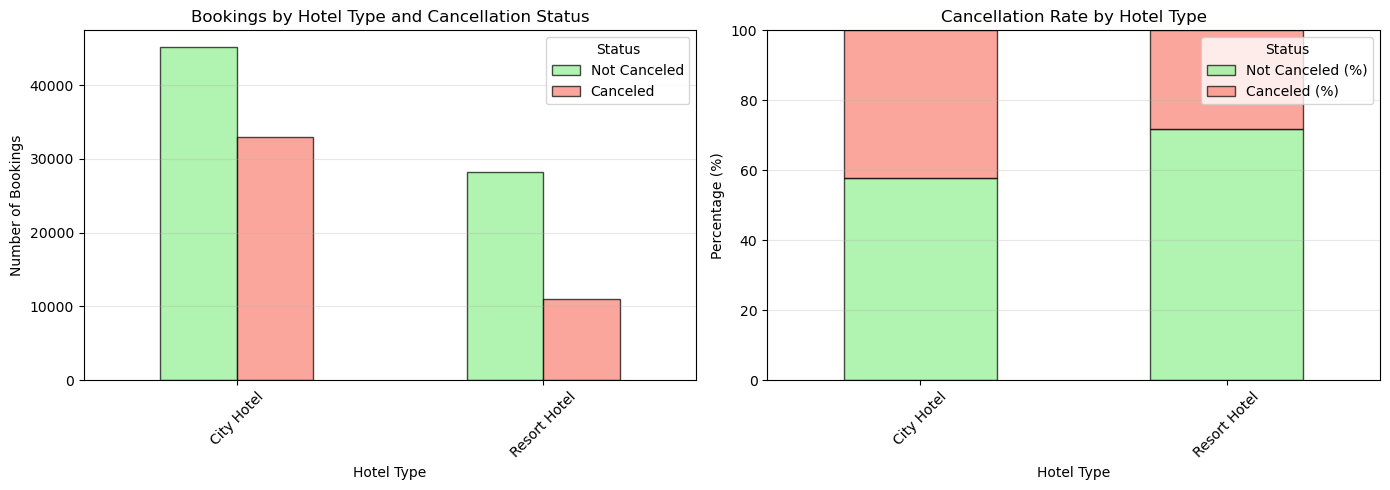


----------------------------------------------------------------------
PERFORMING CHI-SQUARED TEST:
----------------------------------------------------------------------

Test Statistics:
  Chi-squared statistic: 2226.3870
  Degrees of freedom: 1
  P-value: 0.000000
  Significance level: α = 0.05

Expected Frequencies (under null hypothesis):
              Not Canceled  Canceled
hotel                               
City Hotel        48843.05  29278.95
Resort Hotel      24575.95  14732.05

----------------------------------------------------------------------
DECISION:
----------------------------------------------------------------------
P-value (0.000000) < 0.05
REJECT the null hypothesis

Conclusion: There IS a statistically significant difference
in cancellation rates between City and Resort hotels.

----------------------------------------------------------------------
PRACTICAL INTERPRETATION:
----------------------------------------------------------------------

City Hotel:
  

In [55]:
# ----------------------------------------------------------------------------
# HYPOTHESIS TEST 1: CANCELLATION RATES BY HOTEL TYPE
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("HYPOTHESIS TEST 1: CANCELLATION RATES BY HOTEL TYPE")
print("="*70)

# Check if we have the necessary columns
if 'is_canceled' in df_hotel.columns and 'hotel' in df_hotel.columns:
    
    print("\nRESEARCH QUESTION:")
    print("Do City Hotels and Resort Hotels have different cancellation rates?")
    
    print("\n" + "-"*70)
    print("HYPOTHESES:")
    print("-"*70)
    print("H0 (Null): Cancellation rates are the same for both hotel types")
    print("H1 (Alternative): Cancellation rates differ between hotel types")
    
    print("\n" + "-"*70)
    print("TEST SELECTION:")
    print("-"*70)
    print("Chi-squared test of independence")
    print("Reason: We're testing association between two categorical variables")
    print("  - Variable 1: Hotel type (City vs Resort)")
    print("  - Variable 2: Cancellation status (Canceled vs Not Canceled)")
    
    print("\n" + "-"*70)
    print("DATA PREPARATION:")
    print("-"*70)
    
    # Create contingency table
    contingency_table = pd.crosstab(df_hotel['hotel'], df_hotel['is_canceled'])
    contingency_table.columns = ['Not Canceled', 'Canceled']
    
    print("\nContingency Table:")
    print(contingency_table)
    
    # Calculate percentages
    contingency_pct = pd.crosstab(df_hotel['hotel'], df_hotel['is_canceled'], normalize='index') * 100
    contingency_pct.columns = ['Not Canceled (%)', 'Canceled (%)']
    
    print("\nPercentage by Hotel Type:")
    print(contingency_pct.round(2))
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Counts
    contingency_table.plot(kind='bar', ax=axes[0], color=['lightgreen', 'salmon'], 
                          edgecolor='black', alpha=0.7)
    axes[0].set_ylabel('Number of Bookings')
    axes[0].set_title('Bookings by Hotel Type and Cancellation Status')
    axes[0].set_xlabel('Hotel Type')
    axes[0].legend(title='Status')
    axes[0].grid(axis='y', alpha=0.3)
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)
    
    # Percentages
    contingency_pct.plot(kind='bar', ax=axes[1], color=['lightgreen', 'salmon'],
                        edgecolor='black', alpha=0.7, stacked=True)
    axes[1].set_ylabel('Percentage (%)')
    axes[1].set_title('Cancellation Rate by Hotel Type')
    axes[1].set_xlabel('Hotel Type')
    axes[1].legend(title='Status')
    axes[1].set_ylim(0, 100)
    axes[1].grid(axis='y', alpha=0.3)
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "-"*70)
    print("PERFORMING CHI-SQUARED TEST:")
    print("-"*70)
    
    # Perform chi-squared test
    from scipy.stats import chi2_contingency
    
    chi2, p_value, dof, expected_freq = chi2_contingency(contingency_table)
    
    print(f"\nTest Statistics:")
    print(f"  Chi-squared statistic: {chi2:.4f}")
    print(f"  Degrees of freedom: {dof}")
    print(f"  P-value: {p_value:.6f}")
    print(f"  Significance level: α = 0.05")
    
    print(f"\nExpected Frequencies (under null hypothesis):")
    expected_df = pd.DataFrame(expected_freq, 
                              index=contingency_table.index,
                              columns=contingency_table.columns)
    print(expected_df.round(2))
    
    print("\n" + "-"*70)
    print("DECISION:")
    print("-"*70)
    
    if p_value < 0.05:
        print(f"P-value ({p_value:.6f}) < 0.05")
        print("REJECT the null hypothesis")
        print("\nConclusion: There IS a statistically significant difference")
        print("in cancellation rates between City and Resort hotels.")
    else:
        print(f"P-value ({p_value:.6f}) >= 0.05")
        print("FAIL TO REJECT the null hypothesis")
        print("\nConclusion: There is NO statistically significant difference")
        print("in cancellation rates between hotel types.")
    
    print("\n" + "-"*70)
    print("PRACTICAL INTERPRETATION:")
    print("-"*70)
    
    # Calculate actual cancellation rates
    cancel_rates = df_hotel.groupby('hotel')['is_canceled'].mean() * 100
    
    for hotel_type in cancel_rates.index:
        rate = cancel_rates[hotel_type]
        count_canceled = contingency_table.loc[hotel_type, 'Canceled']
        count_total = contingency_table.loc[hotel_type].sum()
        print(f"\n{hotel_type}:")
        print(f"  Cancellation rate: {rate:.2f}%")
        print(f"  Canceled bookings: {count_canceled:,} out of {count_total:,}")
    
    # Calculate difference
    if len(cancel_rates) == 2:
        hotel_types = list(cancel_rates.index)
        rate_diff = abs(cancel_rates[hotel_types[0]] - cancel_rates[hotel_types[1]])
        higher_hotel = hotel_types[0] if cancel_rates[hotel_types[0]] > cancel_rates[hotel_types[1]] else hotel_types[1]
        
        print(f"\nDifference: {rate_diff:.2f} percentage points")
        print(f"{higher_hotel} have higher cancellation rates")
        
        if p_value < 0.05:
            print("\nPRACTICAL SIGNIFICANCE:")
            if rate_diff > 10:
                print(f"The {rate_diff:.1f}% difference is substantial and statistically significant.")
                print(f"Hotel management should consider different cancellation policies")
                print(f"or customer retention strategies for {higher_hotel}.")
            elif rate_diff > 5:
                print(f"The {rate_diff:.1f}% difference is moderate but statistically significant.")
                print(f"This suggests meaningful behavioral differences between customer segments.")
            else:
                print(f"While statistically significant, the {rate_diff:.1f}% difference is small.")
                print(f"Large sample size can detect small effects. Practical impact may be limited.")
    
    print("\n" + "="*70)
    print("HYPOTHESIS TEST 1 COMPLETE")
    print("="*70)
    
else:
    print("\nERROR: Required columns not found in dataset")
    print("Cannot perform cancellation analysis")
    if 'is_canceled' not in df_hotel.columns:
        print("  Missing: 'is_canceled' column")
    if 'hotel' not in df_hotel.columns:
        print("  Missing: 'hotel' column")

In [58]:
# Test 1 Summary
print("\n" + "="*70)
print("HYPOTHESIS TESTING SUMMARY")
print("="*70)

print("\nCompleted Tests:")
print("  1. Chi-squared test: Cancellation rates by hotel type")

if 'is_canceled' in df_hotel.columns and 'hotel' in df_hotel.columns:
    print(f"\nKey Finding:")
    cancel_rates = df_hotel.groupby('hotel')['is_canceled'].mean() * 100
    for hotel_type in cancel_rates.index:
        print(f"  - {hotel_type}: {cancel_rates[hotel_type]:.1f}% cancellation rate")

print("\n" + "="*70)


HYPOTHESIS TESTING SUMMARY

Completed Tests:
  1. Chi-squared test: Cancellation rates by hotel type

Key Finding:
  - City Hotel: 42.2% cancellation rate
  - Resort Hotel: 28.1% cancellation rate



#### Hypothesis Test 2 - Lead Time and Cancellation


HYPOTHESIS TEST 2: LEAD TIME AND CANCELLATION RELATIONSHIP

RESEARCH QUESTION:
Do canceled bookings have different lead times than completed bookings?

----------------------------------------------------------------------
HYPOTHESES:
----------------------------------------------------------------------
H0 (Null): Mean lead time is the same for canceled and completed bookings
H1 (Alternative): Mean lead time differs between canceled and completed bookings

----------------------------------------------------------------------
TEST SELECTION:
----------------------------------------------------------------------
Independent samples T-test
Reason: Comparing means of a continuous variable (lead time) between two groups
  - Group 1: Canceled bookings
  - Group 2: Completed bookings
  - Metric: Lead time (days before arrival)

----------------------------------------------------------------------
DATA PREPARATION:
----------------------------------------------------------------------

Can

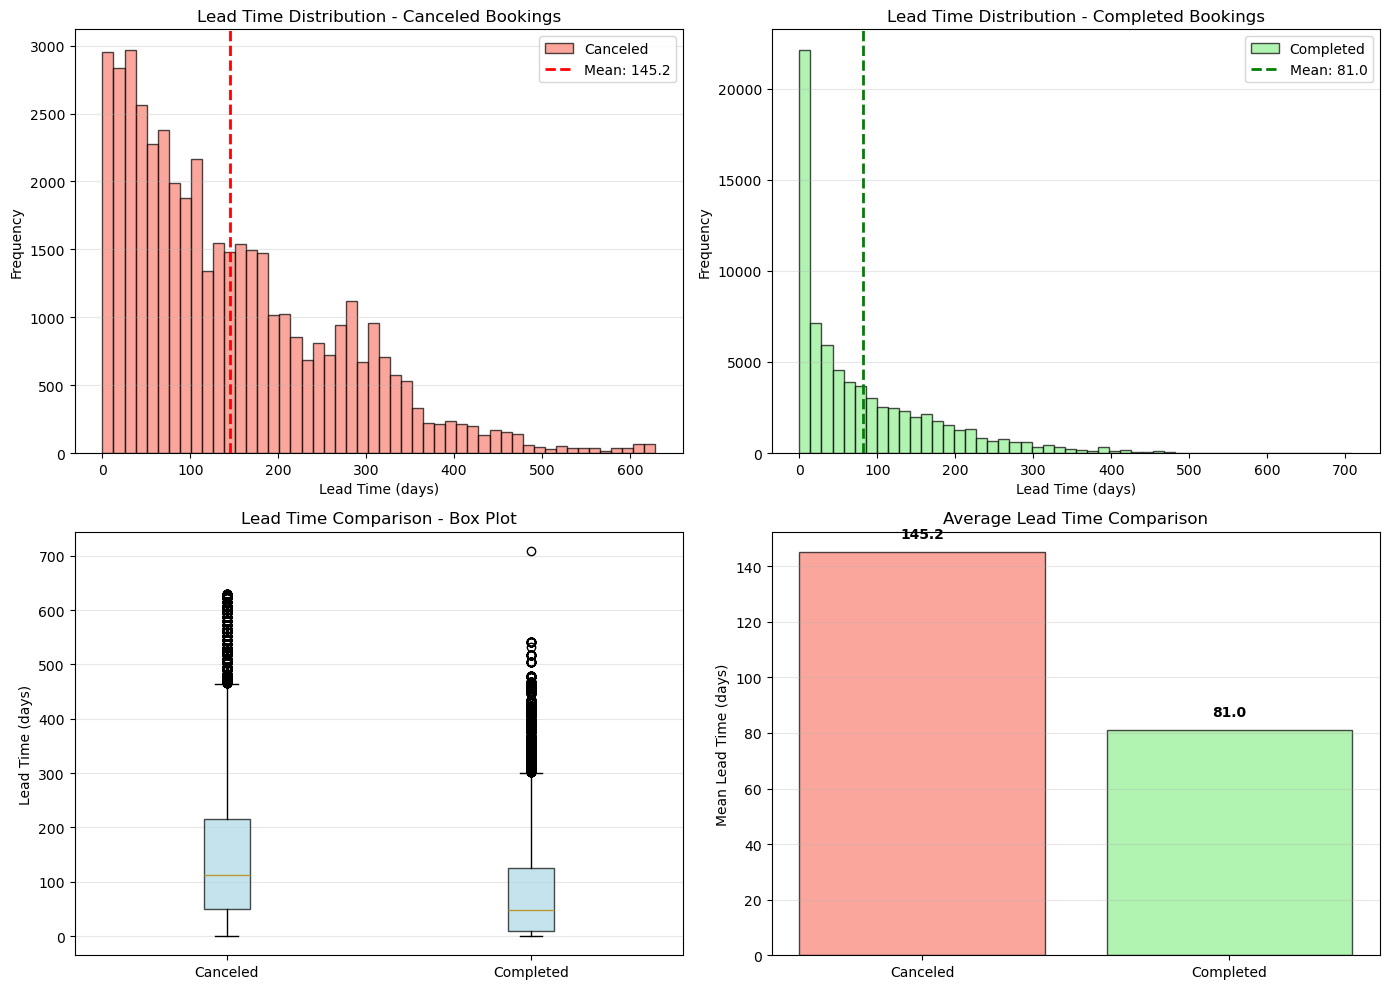


----------------------------------------------------------------------
PERFORMING INDEPENDENT T-TEST:
----------------------------------------------------------------------

Test Statistics:
  T-statistic: 104.0506
  P-value: 0.000000
  Significance level: α = 0.05
  Degrees of freedom (approx): 117,428

----------------------------------------------------------------------
DECISION:
----------------------------------------------------------------------
P-value (0.000000) < 0.05
REJECT the null hypothesis

Conclusion: There IS a statistically significant difference
in lead times between canceled and completed bookings.

----------------------------------------------------------------------
EFFECT SIZE ANALYSIS:
----------------------------------------------------------------------

Cohen's d: 0.6273
Effect size: medium

----------------------------------------------------------------------
PRACTICAL INTERPRETATION:
----------------------------------------------------------------------

In [56]:
# ----------------------------------------------------------------------------
# HYPOTHESIS TEST 2: LEAD TIME IMPACT ON CANCELLATION
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("HYPOTHESIS TEST 2: LEAD TIME AND CANCELLATION RELATIONSHIP")
print("="*70)

# Check if we have the necessary columns
if 'lead_time' in df_hotel.columns and 'is_canceled' in df_hotel.columns:
    
    print("\nRESEARCH QUESTION:")
    print("Do canceled bookings have different lead times than completed bookings?")
    
    print("\n" + "-"*70)
    print("HYPOTHESES:")
    print("-"*70)
    print("H0 (Null): Mean lead time is the same for canceled and completed bookings")
    print("H1 (Alternative): Mean lead time differs between canceled and completed bookings")
    
    print("\n" + "-"*70)
    print("TEST SELECTION:")
    print("-"*70)
    print("Independent samples T-test")
    print("Reason: Comparing means of a continuous variable (lead time) between two groups")
    print("  - Group 1: Canceled bookings")
    print("  - Group 2: Completed bookings")
    print("  - Metric: Lead time (days before arrival)")
    
    print("\n" + "-"*70)
    print("DATA PREPARATION:")
    print("-"*70)
    
    # Separate data by cancellation status
    canceled_leadtime = df_hotel[df_hotel['is_canceled'] == 1]['lead_time'].dropna()
    completed_leadtime = df_hotel[df_hotel['is_canceled'] == 0]['lead_time'].dropna()
    
    print(f"\nCanceled bookings: {len(canceled_leadtime):,} records")
    print(f"  Mean lead time: {canceled_leadtime.mean():.1f} days")
    print(f"  Median lead time: {canceled_leadtime.median():.1f} days")
    print(f"  Std deviation: {canceled_leadtime.std():.1f} days")
    
    print(f"\nCompleted bookings: {len(completed_leadtime):,} records")
    print(f"  Mean lead time: {completed_leadtime.mean():.1f} days")
    print(f"  Median lead time: {completed_leadtime.median():.1f} days")
    print(f"  Std deviation: {completed_leadtime.std():.1f} days")
    
    print(f"\nDifference in means: {abs(canceled_leadtime.mean() - completed_leadtime.mean()):.1f} days")
    
    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Histograms
    axes[0, 0].hist(canceled_leadtime, bins=50, alpha=0.7, color='salmon', 
                    edgecolor='black', label='Canceled')
    axes[0, 0].axvline(canceled_leadtime.mean(), color='red', linestyle='--', 
                      linewidth=2, label=f'Mean: {canceled_leadtime.mean():.1f}')
    axes[0, 0].set_xlabel('Lead Time (days)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Lead Time Distribution - Canceled Bookings')
    axes[0, 0].legend()
    axes[0, 0].grid(axis='y', alpha=0.3)
    
    axes[0, 1].hist(completed_leadtime, bins=50, alpha=0.7, color='lightgreen', 
                    edgecolor='black', label='Completed')
    axes[0, 1].axvline(completed_leadtime.mean(), color='green', linestyle='--', 
                      linewidth=2, label=f'Mean: {completed_leadtime.mean():.1f}')
    axes[0, 1].set_xlabel('Lead Time (days)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Lead Time Distribution - Completed Bookings')
    axes[0, 1].legend()
    axes[0, 1].grid(axis='y', alpha=0.3)
    
    # Box plots
    axes[1, 0].boxplot([canceled_leadtime, completed_leadtime], 
                       labels=['Canceled', 'Completed'],
                       patch_artist=True,
                       boxprops=dict(facecolor='lightblue', alpha=0.7))
    axes[1, 0].set_ylabel('Lead Time (days)')
    axes[1, 0].set_title('Lead Time Comparison - Box Plot')
    axes[1, 0].grid(axis='y', alpha=0.3)
    
    # Mean comparison
    means = [canceled_leadtime.mean(), completed_leadtime.mean()]
    axes[1, 1].bar(['Canceled', 'Completed'], means, 
                   color=['salmon', 'lightgreen'], edgecolor='black', alpha=0.7)
    axes[1, 1].set_ylabel('Mean Lead Time (days)')
    axes[1, 1].set_title('Average Lead Time Comparison')
    axes[1, 1].grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(means):
        axes[1, 1].text(i, v + 5, f'{v:.1f}', ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "-"*70)
    print("PERFORMING INDEPENDENT T-TEST:")
    print("-"*70)
    
    # Perform t-test
    from scipy.stats import ttest_ind
    
    t_statistic, p_value = ttest_ind(canceled_leadtime, completed_leadtime)
    
    print(f"\nTest Statistics:")
    print(f"  T-statistic: {t_statistic:.4f}")
    print(f"  P-value: {p_value:.6f}")
    print(f"  Significance level: α = 0.05")
    
    # Degrees of freedom (approximate)
    n1 = len(canceled_leadtime)
    n2 = len(completed_leadtime)
    df_approx = n1 + n2 - 2
    print(f"  Degrees of freedom (approx): {df_approx:,}")
    
    print("\n" + "-"*70)
    print("DECISION:")
    print("-"*70)
    
    if p_value < 0.05:
        print(f"P-value ({p_value:.6f}) < 0.05")
        print("REJECT the null hypothesis")
        print("\nConclusion: There IS a statistically significant difference")
        print("in lead times between canceled and completed bookings.")
    else:
        print(f"P-value ({p_value:.6f}) >= 0.05")
        print("FAIL TO REJECT the null hypothesis")
        print("\nConclusion: There is NO statistically significant difference")
        print("in lead times between booking outcomes.")
    
    print("\n" + "-"*70)
    print("EFFECT SIZE ANALYSIS:")
    print("-"*70)
    
    # Cohen's d effect size
    pooled_std = np.sqrt(((n1-1)*canceled_leadtime.std()**2 + (n2-1)*completed_leadtime.std()**2) / (n1+n2-2))
    cohens_d = (canceled_leadtime.mean() - completed_leadtime.mean()) / pooled_std
    
    print(f"\nCohen's d: {cohens_d:.4f}")
    
    if abs(cohens_d) < 0.2:
        effect_size = "negligible"
    elif abs(cohens_d) < 0.5:
        effect_size = "small"
    elif abs(cohens_d) < 0.8:
        effect_size = "medium"
    else:
        effect_size = "large"
    
    print(f"Effect size: {effect_size}")
    
    print("\n" + "-"*70)
    print("PRACTICAL INTERPRETATION:")
    print("-"*70)
    
    mean_diff = canceled_leadtime.mean() - completed_leadtime.mean()
    
    if mean_diff > 0:
        print(f"\nCanceled bookings are made {mean_diff:.1f} days earlier on average")
        
        if p_value < 0.05:
            print("\nPRACTICAL IMPLICATIONS:")
            if mean_diff > 30:
                print(f"- Bookings made {mean_diff:.0f} days in advance carry significantly higher cancellation risk")
                print("- Early bookings likely reflect tentative plans or price speculation")
                print("- Hotels should consider stricter cancellation policies for far-advance bookings")
            elif mean_diff > 14:
                print(f"- {mean_diff:.0f}-day advance bookings show moderately higher cancellation rates")
                print("- May indicate customers booking multiple options")
                print("- Consider tiered cancellation policies based on lead time")
            else:
                print(f"- Small but significant {mean_diff:.0f}-day difference detected")
                print("- Effect is statistically significant but practically minor")
    else:
        print(f"\nCompleted bookings are made {abs(mean_diff):.1f} days earlier on average")
        
        if p_value < 0.05:
            print("\nPRACTICAL IMPLICATIONS:")
            print("- Last-minute bookings show higher cancellation rates")
            print("- May reflect urgent needs with uncertain plans")
            print("- Consider requiring immediate payment for short-notice bookings")
    
    # Recommendation based on findings
    print("\n" + "-"*70)
    print("BUSINESS RECOMMENDATION:")
    print("-"*70)
    
    if p_value < 0.05 and abs(mean_diff) > 20:
        print("\nSTRONG RECOMMENDATION:")
        print("Implement lead-time-based cancellation policies:")
        if mean_diff > 0:
            print(f"  - Bookings >90 days advance: Require deposit or stricter cancellation terms")
            print(f"  - Bookings 30-90 days: Standard flexible policy")
            print(f"  - Bookings <30 days: Most lenient terms (lower cancellation risk)")
        else:
            print(f"  - Last-minute bookings (<7 days): Require immediate payment")
            print(f"  - Short-notice bookings show higher cancellation likelihood")
    elif p_value < 0.05:
        print("\nMODERATE RECOMMENDATION:")
        print("Lead time shows statistically significant but small effect on cancellations")
        print("Consider as one factor among many in cancellation risk modeling")
    else:
        print("\nNO RECOMMENDATION:")
        print("Lead time is not a significant predictor of cancellation")
        print("Focus on other factors (price, customer type, season, etc.)")
    
    print("\n" + "="*70)
    print("HYPOTHESIS TEST 2 COMPLETE")
    print("="*70)
    
else:
    print("\nERROR: Required columns not found in dataset")
    print("Cannot perform lead time analysis")
    if 'lead_time' not in df_hotel.columns:
        print("  Missing: 'lead_time' column")
    if 'is_canceled' not in df_hotel.columns:
        print("  Missing: 'is_canceled' column")

In [57]:
# Hypothesis Testing Summary (Updated)
print("\n" + "="*70)
print("HYPOTHESIS TESTING SUMMARY")
print("="*70)

print("\nCompleted Tests:")
print("  1. Chi-squared test: Cancellation rates by hotel type")
print("  2. Independent T-test: Lead time impact on cancellation")

print("\n" + "-"*70)
print("KEY FINDINGS:")
print("-"*70)

# Test 1 summary
if 'is_canceled' in df_hotel.columns and 'hotel' in df_hotel.columns:
    cancel_rates = df_hotel.groupby('hotel')['is_canceled'].mean() * 100
    print("\nTest 1 - Cancellation by Hotel Type:")
    for hotel_type in cancel_rates.index:
        print(f"  - {hotel_type}: {cancel_rates[hotel_type]:.1f}% cancellation rate")

# Test 2 summary
if 'lead_time' in df_hotel.columns and 'is_canceled' in df_hotel.columns:
    canceled_lead = df_hotel[df_hotel['is_canceled'] == 1]['lead_time'].mean()
    completed_lead = df_hotel[df_hotel['is_canceled'] == 0]['lead_time'].mean()
    print("\nTest 2 - Lead Time and Cancellation:")
    print(f"  - Canceled bookings: {canceled_lead:.1f} days average lead time")
    print(f"  - Completed bookings: {completed_lead:.1f} days average lead time")
    print(f"  - Difference: {abs(canceled_lead - completed_lead):.1f} days")

print("\n" + "="*70)


HYPOTHESIS TESTING SUMMARY

Completed Tests:
  1. Chi-squared test: Cancellation rates by hotel type
  2. Independent T-test: Lead time impact on cancellation

----------------------------------------------------------------------
KEY FINDINGS:
----------------------------------------------------------------------

Test 1 - Cancellation by Hotel Type:
  - City Hotel: 42.2% cancellation rate
  - Resort Hotel: 28.1% cancellation rate

Test 2 - Lead Time and Cancellation:
  - Canceled bookings: 145.2 days average lead time
  - Completed bookings: 81.0 days average lead time
  - Difference: 64.2 days



#### Hypothesis Test 3 - Room Type and Price (ANOVA)


HYPOTHESIS TEST 3: PRICE VARIATION ACROSS ROOM TYPES (AIRBNB)

RESEARCH QUESTION:
Do different Airbnb room types have significantly different average prices?

----------------------------------------------------------------------
HYPOTHESES:
----------------------------------------------------------------------
H0 (Null): All room types have the same mean price
H1 (Alternative): At least one room type has a different mean price

----------------------------------------------------------------------
TEST SELECTION:
----------------------------------------------------------------------
One-way ANOVA (Analysis of Variance)
Reason: Comparing means across multiple independent groups
  - Independent variable: Room type (categorical, 4 categories)
  - Dependent variable: Price (continuous)
  - Groups: Different room/property types

----------------------------------------------------------------------
DATA PREPARATION:
----------------------------------------------------------------------

R

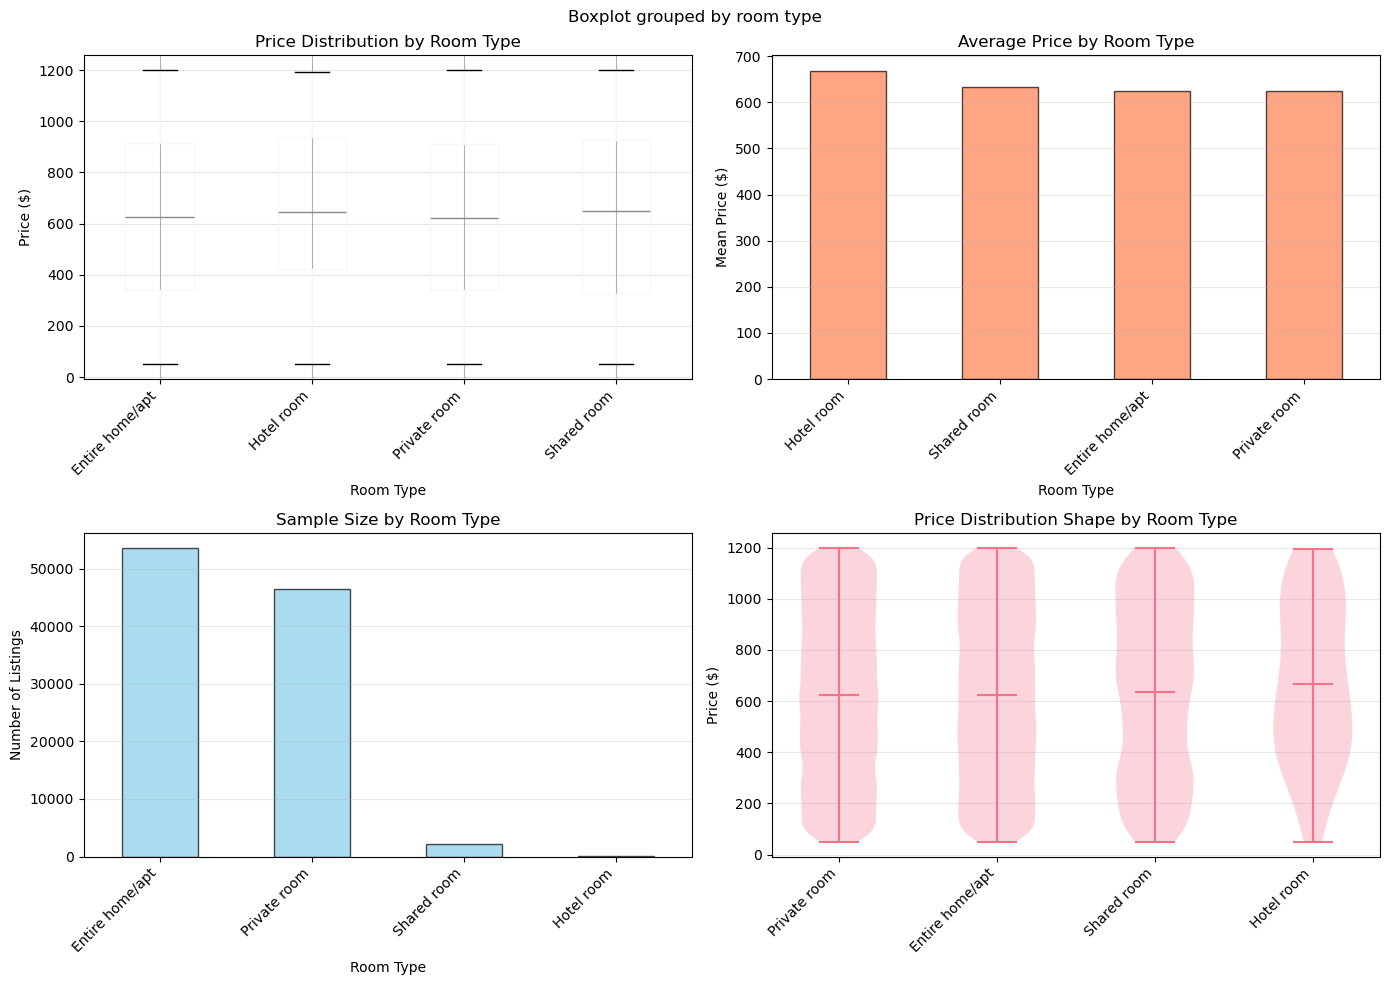


----------------------------------------------------------------------
PERFORMING ONE-WAY ANOVA:
----------------------------------------------------------------------

Test Statistics:
  F-statistic: 1.1989
  P-value: 0.308426
  Significance level: α = 0.05
  Degrees of freedom (between groups): 3
  Degrees of freedom (within groups): 102348

----------------------------------------------------------------------
DECISION:
----------------------------------------------------------------------
P-value (0.308426) >= 0.05
FAIL TO REJECT the null hypothesis

Conclusion: There is NO statistically significant difference
in mean prices across room types.

----------------------------------------------------------------------
EFFECT SIZE ANALYSIS:
----------------------------------------------------------------------

Eta-squared (η²): 0.0000
Interpretation: Room type explains 0.00% of price variance
Effect size: negligible

--------------------------------------------------------------------

In [59]:
# ----------------------------------------------------------------------------
# HYPOTHESIS TEST 3: AIRBNB ROOM TYPE AND PRICE RELATIONSHIP
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("HYPOTHESIS TEST 3: PRICE VARIATION ACROSS ROOM TYPES (AIRBNB)")
print("="*70)

# Find room type column
room_type_cols = ['room type', 'room_type', 'Room Type', 'room Type']
room_col = None
for col in room_type_cols:
    if col in df_airbnb.columns:
        room_col = col
        break

# Find price column (use the one from earlier analysis)
price_col = None
for col in df_airbnb.columns:
    if 'price' in col.lower():
        price_col = col
        break

if room_col and price_col:
    
    print("\nRESEARCH QUESTION:")
    print("Do different Airbnb room types have significantly different average prices?")
    
    print("\n" + "-"*70)
    print("HYPOTHESES:")
    print("-"*70)
    print("H0 (Null): All room types have the same mean price")
    print("H1 (Alternative): At least one room type has a different mean price")
    
    print("\n" + "-"*70)
    print("TEST SELECTION:")
    print("-"*70)
    print("One-way ANOVA (Analysis of Variance)")
    print("Reason: Comparing means across multiple independent groups")
    print(f"  - Independent variable: Room type (categorical, {df_airbnb[room_col].nunique()} categories)")
    print(f"  - Dependent variable: Price (continuous)")
    print("  - Groups: Different room/property types")
    
    print("\n" + "-"*70)
    print("DATA PREPARATION:")
    print("-"*70)
    
    # Clean price data
    df_airbnb_test = df_airbnb[[room_col, price_col]].copy()
    
    # Handle price cleaning if needed
    if df_airbnb_test[price_col].dtype == 'object':
        df_airbnb_test[price_col] = df_airbnb_test[price_col].astype(str).str.replace('$', '', regex=False)
        df_airbnb_test[price_col] = df_airbnb_test[price_col].str.replace(',', '', regex=False)
        df_airbnb_test[price_col] = pd.to_numeric(df_airbnb_test[price_col], errors='coerce')
    
    # Remove missing values and invalid prices
    df_airbnb_test = df_airbnb_test.dropna()
    df_airbnb_test = df_airbnb_test[df_airbnb_test[price_col] > 0]
    
    # Get top room types (at least 30 samples each for valid comparison)
    room_counts = df_airbnb_test[room_col].value_counts()
    valid_rooms = room_counts[room_counts >= 30].index.tolist()
    
    if len(valid_rooms) < 2:
        print("\nERROR: Not enough room types with sufficient sample sizes")
        print("Need at least 2 room types with 30+ listings each")
    else:
        # Filter to valid room types
        df_airbnb_test = df_airbnb_test[df_airbnb_test[room_col].isin(valid_rooms)]
        
        # Limit to top 5 room types for clarity
        top_rooms = room_counts.head(5).index.tolist()
        df_airbnb_test = df_airbnb_test[df_airbnb_test[room_col].isin(top_rooms)]
        
        print(f"\nRoom types included in analysis: {len(df_airbnb_test[room_col].unique())}")
        print(f"Total listings: {len(df_airbnb_test):,}")
        
        print("\nDescriptive Statistics by Room Type:")
        print("-"*70)
        
        room_stats = df_airbnb_test.groupby(room_col)[price_col].agg(['count', 'mean', 'median', 'std'])
        room_stats.columns = ['Count', 'Mean', 'Median', 'Std Dev']
        print(room_stats.round(2))
        
        # Visualizations
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        # Box plot
        df_airbnb_test.boxplot(column=price_col, by=room_col, ax=axes[0, 0])
        axes[0, 0].set_xlabel('Room Type')
        axes[0, 0].set_ylabel('Price ($)')
        axes[0, 0].set_title('Price Distribution by Room Type')
        plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=45, ha='right')
        axes[0, 0].grid(axis='y', alpha=0.3)
        
        # Mean comparison bar chart
        room_means = df_airbnb_test.groupby(room_col)[price_col].mean().sort_values(ascending=False)
        room_means.plot(kind='bar', ax=axes[0, 1], color='coral', edgecolor='black', alpha=0.7)
        axes[0, 1].set_ylabel('Mean Price ($)')
        axes[0, 1].set_title('Average Price by Room Type')
        axes[0, 1].set_xlabel('Room Type')
        plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=45, ha='right')
        axes[0, 1].grid(axis='y', alpha=0.3)
        
        # Count by room type
        room_counts_plot = df_airbnb_test[room_col].value_counts()
        room_counts_plot.plot(kind='bar', ax=axes[1, 0], color='skyblue', edgecolor='black', alpha=0.7)
        axes[1, 0].set_ylabel('Number of Listings')
        axes[1, 0].set_title('Sample Size by Room Type')
        axes[1, 0].set_xlabel('Room Type')
        plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45, ha='right')
        axes[1, 0].grid(axis='y', alpha=0.3)
        
        # Violin plot for distribution shape
        room_data = [df_airbnb_test[df_airbnb_test[room_col] == room][price_col].values 
                     for room in df_airbnb_test[room_col].unique()]
        axes[1, 1].violinplot(room_data, positions=range(len(room_data)), showmeans=True)
        axes[1, 1].set_xticks(range(len(df_airbnb_test[room_col].unique())))
        axes[1, 1].set_xticklabels(df_airbnb_test[room_col].unique(), rotation=45, ha='right')
        axes[1, 1].set_ylabel('Price ($)')
        axes[1, 1].set_title('Price Distribution Shape by Room Type')
        axes[1, 1].grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print("\n" + "-"*70)
        print("PERFORMING ONE-WAY ANOVA:")
        print("-"*70)
        
        # Prepare data for ANOVA
        from scipy.stats import f_oneway
        
        groups = [df_airbnb_test[df_airbnb_test[room_col] == room][price_col].values 
                  for room in df_airbnb_test[room_col].unique()]
        
        # Perform ANOVA
        f_statistic, p_value = f_oneway(*groups)
        
        print(f"\nTest Statistics:")
        print(f"  F-statistic: {f_statistic:.4f}")
        print(f"  P-value: {p_value:.6f}")
        print(f"  Significance level: α = 0.05")
        
        # Degrees of freedom
        k = len(groups)  # number of groups
        N = len(df_airbnb_test)  # total sample size
        df_between = k - 1
        df_within = N - k
        
        print(f"  Degrees of freedom (between groups): {df_between}")
        print(f"  Degrees of freedom (within groups): {df_within}")
        
        print("\n" + "-"*70)
        print("DECISION:")
        print("-"*70)
        
        if p_value < 0.05:
            print(f"P-value ({p_value:.6f}) < 0.05")
            print("REJECT the null hypothesis")
            print("\nConclusion: There IS a statistically significant difference")
            print("in mean prices across different room types.")
        else:
            print(f"P-value ({p_value:.6f}) >= 0.05")
            print("FAIL TO REJECT the null hypothesis")
            print("\nConclusion: There is NO statistically significant difference")
            print("in mean prices across room types.")
        
        print("\n" + "-"*70)
        print("EFFECT SIZE ANALYSIS:")
        print("-"*70)
        
        # Eta-squared (η²) - proportion of variance explained
        grand_mean = df_airbnb_test[price_col].mean()
        
        # Between-group sum of squares
        ss_between = sum([len(df_airbnb_test[df_airbnb_test[room_col] == room]) * 
                         (df_airbnb_test[df_airbnb_test[room_col] == room][price_col].mean() - grand_mean)**2 
                         for room in df_airbnb_test[room_col].unique()])
        
        # Total sum of squares
        ss_total = sum((df_airbnb_test[price_col] - grand_mean)**2)
        
        eta_squared = ss_between / ss_total
        
        print(f"\nEta-squared (η²): {eta_squared:.4f}")
        print(f"Interpretation: Room type explains {eta_squared*100:.2f}% of price variance")
        
        if eta_squared < 0.01:
            effect = "negligible"
        elif eta_squared < 0.06:
            effect = "small"
        elif eta_squared < 0.14:
            effect = "medium"
        else:
            effect = "large"
        
        print(f"Effect size: {effect}")
        
        print("\n" + "-"*70)
        print("PRACTICAL INTERPRETATION:")
        print("-"*70)
        
        # Find most and least expensive room types
        most_expensive = room_means.index[0]
        least_expensive = room_means.index[-1]
        price_range = room_means.iloc[0] - room_means.iloc[-1]
        
        print(f"\nPrice Range Across Room Types:")
        print(f"  Most expensive: {most_expensive} (${room_means.iloc[0]:.2f} avg)")
        print(f"  Least expensive: {least_expensive} (${room_means.iloc[-1]:.2f} avg)")
        print(f"  Difference: ${price_range:.2f} ({(price_range/room_means.iloc[-1]*100):.1f}% premium)")
        
        if p_value < 0.05:
            print("\nPRACTICAL IMPLICATIONS:")
            
            if price_range > 100:
                print(f"- Room type is a major price determinant (${price_range:.0f} difference)")
                print(f"- {most_expensive} command significant premium over {least_expensive}")
                print("- Customers value privacy, space, and amenities differently")
                print("\nFor hosts:")
                print(f"  * Converting to {most_expensive} could increase revenue significantly")
                print(f"  * {least_expensive} serves budget-conscious market segment")
            elif price_range > 50:
                print(f"- Moderate price differences across room types (${price_range:.0f})")
                print(f"- Room type influences pricing but other factors also matter")
            else:
                print(f"- Small price differences despite statistical significance")
                print(f"- Room type less important than other factors (location, amenities)")
        
        print("\n" + "-"*70)
        print("POST-HOC ANALYSIS:")
        print("-"*70)
        
        if p_value < 0.05:
            print("\nPairwise Comparisons (largest differences):")
            
            # Compare each pair
            room_list = list(room_means.index)
            comparisons = []
            
            for i in range(len(room_list)):
                for j in range(i+1, len(room_list)):
                    room1 = room_list[i]
                    room2 = room_list[j]
                    mean1 = room_means[room1]
                    mean2 = room_means[room2]
                    diff = abs(mean1 - mean2)
                    comparisons.append((room1, room2, diff, mean1, mean2))
            
            # Sort by difference
            comparisons.sort(key=lambda x: x[2], reverse=True)
            
            # Show top 3 comparisons
            for i, (r1, r2, diff, m1, m2) in enumerate(comparisons[:3], 1):
                print(f"\n{i}. {r1} vs {r2}:")
                print(f"   ${m1:.2f} vs ${m2:.2f} (${diff:.2f} difference)")
                print(f"   {(diff/min(m1,m2)*100):.1f}% price premium")
        else:
            print("\nNo significant differences found - post-hoc analysis not needed")
        
        print("\n" + "-"*70)
        print("BUSINESS RECOMMENDATION:")
        print("-"*70)
        
        if p_value < 0.05 and price_range > 75:
            print("\nSTRONG RECOMMENDATION:")
            print("Room type significantly impacts pricing strategy:")
            print(f"  1. Premium positioning for {most_expensive} ({room_means.iloc[0]:.0f}% above average)")
            print(f"  2. Budget strategy for {least_expensive} (volume-based)")
            print(f"  3. Consider property upgrades to move into higher-priced categories")
            print(f"  4. Market segmentation based on traveler needs (privacy vs cost)")
        elif p_value < 0.05:
            print("\nMODERATE RECOMMENDATION:")
            print("Room type influences price but effect is modest")
            print("Focus on:")
            print("  - Location quality")
            print("  - Amenities and features")
            print("  - Host ratings and reviews")
            print("  - Seasonal pricing adjustments")
        else:
            print("\nNO STRONG RECOMMENDATION:")
            print("Room type is not a primary price driver in this market")
            print("Focus on other differentiation factors")
        
        print("\n" + "="*70)
        print("HYPOTHESIS TEST 3 COMPLETE")
        print("="*70)

else:
    print("\nERROR: Required columns not found in dataset")
    if not room_col:
        print("  Missing: Room type column")
        print("  Checked columns:", room_type_cols)
    if not price_col:
        print("  Missing: Price column")

In [60]:
# Hypothesis Testing Summary (Final)
print("\n" + "="*70)
print("HYPOTHESIS TESTING - COMPLETE SUMMARY")
print("="*70)

print("\nAll Completed Tests:")
print("  1. Chi-squared test: Cancellation rates by hotel type")
print("  2. Independent T-test: Lead time impact on cancellation")
print("  3. One-way ANOVA: Room type impact on Airbnb prices")

print("\n" + "="*70)
print("KEY FINDINGS ACROSS ALL TESTS:")
print("="*70)

# Test 1 summary
if 'is_canceled' in df_hotel.columns and 'hotel' in df_hotel.columns:
    cancel_rates = df_hotel.groupby('hotel')['is_canceled'].mean() * 100
    print("\nTest 1 - Hotel Type and Cancellation:")
    for hotel_type in cancel_rates.index:
        print(f"  - {hotel_type}: {cancel_rates[hotel_type]:.1f}% cancellation rate")
    
    chi2_data = pd.crosstab(df_hotel['hotel'], df_hotel['is_canceled'])
    chi2, p_val, _, _ = chi2_contingency(chi2_data)
    result = "Significant" if p_val < 0.05 else "Not significant"
    print(f"  Result: {result} (p={p_val:.4f})")

# Test 2 summary
if 'lead_time' in df_hotel.columns and 'is_canceled' in df_hotel.columns:
    canceled_lead = df_hotel[df_hotel['is_canceled'] == 1]['lead_time'].mean()
    completed_lead = df_hotel[df_hotel['is_canceled'] == 0]['lead_time'].mean()
    print("\nTest 2 - Lead Time and Cancellation:")
    print(f"  - Canceled: {canceled_lead:.1f} days lead time")
    print(f"  - Completed: {completed_lead:.1f} days lead time")
    print(f"  - Difference: {abs(canceled_lead - completed_lead):.1f} days")
    
    t_stat, p_val = ttest_ind(
        df_hotel[df_hotel['is_canceled'] == 1]['lead_time'].dropna(),
        df_hotel[df_hotel['is_canceled'] == 0]['lead_time'].dropna()
    )
    result = "Significant" if p_val < 0.05 else "Not significant"
    print(f"  Result: {result} (p={p_val:.4f})")

# Test 3 summary
if room_col and price_col:
    print("\nTest 3 - Room Type and Price (Airbnb):")
    room_means = df_airbnb_test.groupby(room_col)[price_col].mean().sort_values(ascending=False)
    print(f"  - Most expensive: {room_means.index[0]} (${room_means.iloc[0]:.2f})")
    print(f"  - Least expensive: {room_means.index[-1]} (${room_means.iloc[-1]:.2f})")
    print(f"  - Price range: ${room_means.iloc[0] - room_means.iloc[-1]:.2f}")
    
    groups = [df_airbnb_test[df_airbnb_test[room_col] == room][price_col].values 
              for room in df_airbnb_test[room_col].unique()]
    f_stat, p_val = f_oneway(*groups)
    result = "Significant" if p_val < 0.05 else "Not significant"
    print(f"  Result: {result} (p={p_val:.4f})")

print("\n" + "="*70)
print("STATISTICAL ANALYSIS SECTION COMPLETE")
print("="*70)


HYPOTHESIS TESTING - COMPLETE SUMMARY

All Completed Tests:
  1. Chi-squared test: Cancellation rates by hotel type
  2. Independent T-test: Lead time impact on cancellation
  3. One-way ANOVA: Room type impact on Airbnb prices

KEY FINDINGS ACROSS ALL TESTS:

Test 1 - Hotel Type and Cancellation:
  - City Hotel: 42.2% cancellation rate
  - Resort Hotel: 28.1% cancellation rate
  Result: Significant (p=0.0000)

Test 2 - Lead Time and Cancellation:
  - Canceled: 145.2 days lead time
  - Completed: 81.0 days lead time
  - Difference: 64.2 days
  Result: Significant (p=0.0000)

Test 3 - Room Type and Price (Airbnb):
  - Most expensive: Hotel room ($668.47)
  - Least expensive: Private room ($625.01)
  - Price range: $43.46
  Result: Not significant (p=0.3084)

STATISTICAL ANALYSIS SECTION COMPLETE
